# LAB WORK 2 - Task 2: Developing a simple Recommender engine using KNearestNeighbors 

## Subtask A - Print the userID and movieID rating matrix

#### Opening and analysis of the datasets

In [1]:
import pandas as pd

#openeing the two datasets using pandas to better handle the data
ratings = pd.read_csv("UserID-rating 2.csv", sep=";")
movies = pd.read_csv("moviesId-title-1.cvs.csv", sep=";")

#First overview of what the titles of the datasets are
print(ratings.columns)
print(ratings.shape)

print(movies.columns)
print(movies.shape)

Index(['UserID', 'MovieID', 'rating'], dtype='object')
(310, 3)
Index(['Title', 'movieId'], dtype='object')
(31, 2)


In [2]:
#Visualizing both datasets 
print(ratings)
print()
print(movies)

     UserID  MovieID  rating
0         0        0       3
1         0        1       0
2         0        2       1
3         0        3       5
4         0        4       4
..      ...      ...     ...
305       9       26       1
306       9       27       1
307       9       28       2
308       9       29       3
309       9       30       4

[310 rows x 3 columns]

                                  Title  movieId
0   Tyler Perry's Why Did I get Married        0
1               Twilight: Breaking Dawn        1
2                              Twilight        2
3                        The Ugly Truth        3
4              The Time Traveler's Wife        4
5                          The Proposal        5
6                The Invention of Lying        6
7                    The Heartbreak Kid        7
8                           The Duchess        8
9   The Curious Case of Benjamin Button        9
10                     The Back-up Plan       10
11                              Tangled

#### Display of the userID & movieID rating matrix

In [3]:
matrix = ratings.pivot(index="MovieID", columns="UserID", values="rating").fillna(0)
#print(matrix.head())
matrix

UserID,0,1,2,3,4,5,6,7,8,9
MovieID,,,,,,,,,,
0,3,5,1,2,5,1,4,1,5,1
1,0,4,1,1,5,2,3,1,5,2
2,1,3,1,0,5,3,4,1,5,3
3,5,2,5,4,1,4,1,1,4,4
4,4,11,5,4,1,5,1,0,4,5
5,2,2,4,4,1,4,1,0,4,55
6,5,3,4,4,1,3,0,0,1,5
7,0,4,2,2,1,2,0,3,2,5
8,2,5,2,2,1,1,0,3,3,4


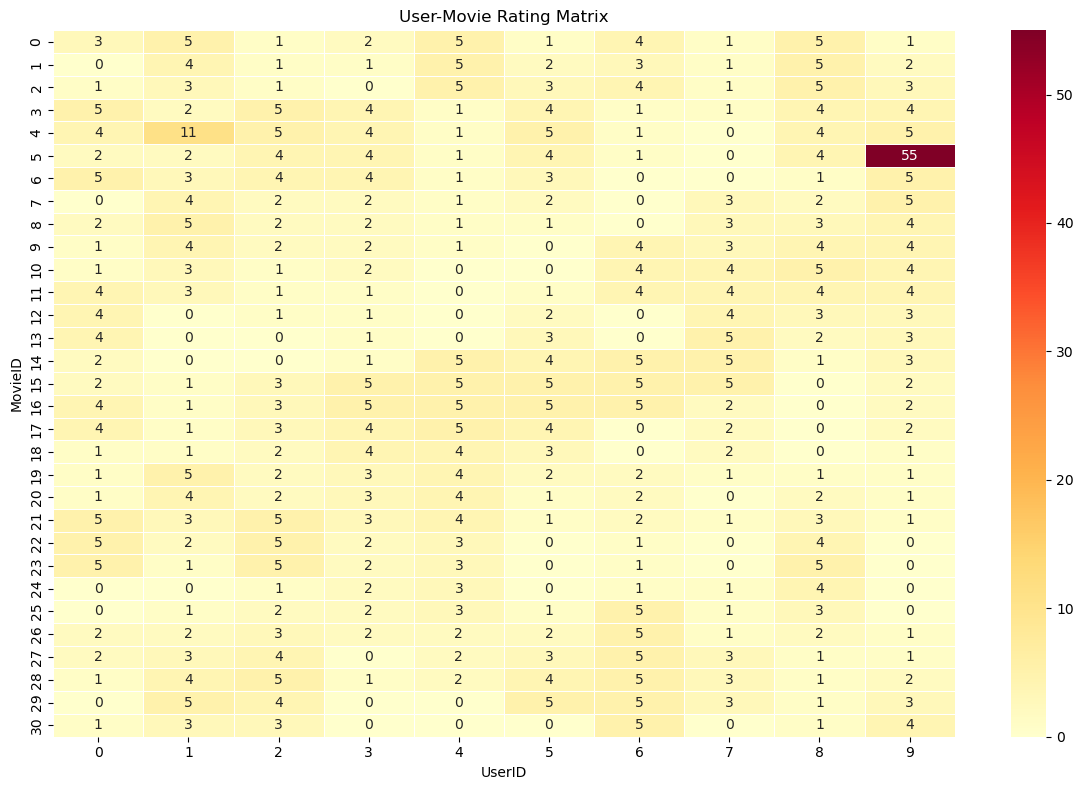

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(matrix, 
            annot=True,        # show the numbers inside cells
            fmt=".0f",         # no decimal places
            cmap="YlOrRd",     # color scale: yellow = low, red = high
            linewidths=0.5)    # grid lines between cells

plt.title("User-Movie Rating Matrix")
plt.xlabel("UserID")
plt.ylabel("MovieID")
plt.tight_layout()
plt.show()

## Subtask B - Program a movie recommender system using KNnearestNeighbors-Algorithm

We have used the provided learning materials in the task description, namely the sklearn neighbors module and the lecture slides of Pr. R. Jaeger to understand what to do and the way to do it for our specific task.

We separated the implementation in two parts : Euclidean Distance and Manhattan distance.

#### Using Euclidean Metric

In [12]:
from sklearn.neighbors import NearestNeighbors

#We initialise the NearestNeighbors model to the knn_algo_eu and specify the euclidean metric 
#and brute algorithm : compare the one movie with all the others by computing the euclidean distances and comparing whihc is the highest values
knn_algo_eu = NearestNeighbors(metric="euclidean", algorithm="brute")

#fit the NearestNieghbors model to our dataset
knn_algo_eu.fit(matrix)

#query_eu=1
movie_name0 = input("QUERY : Please enter your movie title : ")
query_eu = movies[movies["Title"] == movie_name0]["movieId"].values[0]

distances_eu, indexes_eu = knn_algo_eu.kneighbors(matrix.iloc[query_eu,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix.index[query_eu]}, {movie_name0}, are :")
print()
for i in range(1, len(distances_eu.flatten())):
    movie_eu_idx = matrix.index[indexes_eu.flatten()[i]]
    title = movies[movies["movieId"] == movie_eu_idx]["Title"].values[0]
    distance_eu = distances_eu.flatten()[i]
    print(f'recommended movie {movie_eu_idx}, {title}, with a Euclidean distance of {distance_eu}')

QUERY : Please enter your movie title :  The Proposal


The Recommendations for movie 5, The Proposal, are :

recommended movie 6, The Invention of Lying, with a Euclidean distance of 50.20956084253277
recommended movie 7, The Heartbreak Kid, with a Euclidean distance of 50.33885179461288
recommended movie 4, The Time Traveler's Wife, with a Euclidean distance of 50.86255990411808
recommended movie 3, The Ugly Truth, with a Euclidean distance of 51.10772935672255
recommended movie 8, The Duchess, with a Euclidean distance of 51.36146415358503


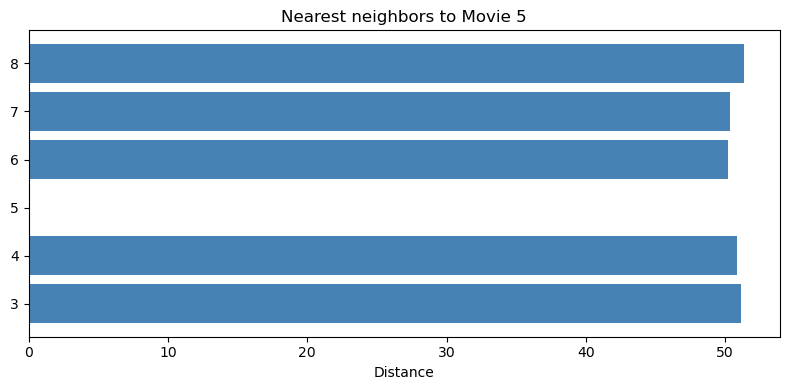

In [19]:
query_movie = matrix.index[query_eu]
neighbor_movies = [matrix.index[indexes_eu.flatten()[i]] for i in range(len(distances_eu.flatten()))]
neighbor_distances = distances_eu.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies, neighbor_distances, color="steelblue")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie}")
plt.tight_layout()
plt.show()

#### Using Manhattan Metric

In [15]:
knn_algo_man = NearestNeighbors(metric="manhattan", algorithm="brute")

knn_algo_man.fit(matrix)

#query_man=1
movie_name1 = input("QUERY : Please enter your movie title : ")
query_man = movies[movies["Title"] == movie_name1]["movieId"].values[0]

distances_man, indexes_man = knn_algo_man.kneighbors(matrix.iloc[query_man,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix.index[query_man]}, {movie_name1}, are :")
print()
for i in range(1, len(distances_man.flatten())):
    movie_man_idx = matrix.index[indexes_man.flatten()[i]]
    title = movies[movies["movieId"] == movie_man_idx]["Title"].values[0]
    distance_man = distances_man.flatten()[i]
    print(f'recommended movie {movie_man_idx}, {title}, with a Manhattan distance of {distance_man}')

QUERY : Please enter your movie title :  The Proposal


The Recommendations for movie 5, The Proposal, are :

recommended movie 3, The Ugly Truth, with a Manhattan distance of 56.0
recommended movie 6, The Invention of Lying, with a Manhattan distance of 59.0
recommended movie 4, The Time Traveler's Wife, with a Manhattan distance of 63.0
recommended movie 7, The Heartbreak Kid, with a Manhattan distance of 66.0
recommended movie 8, The Duchess, with a Manhattan distance of 66.0


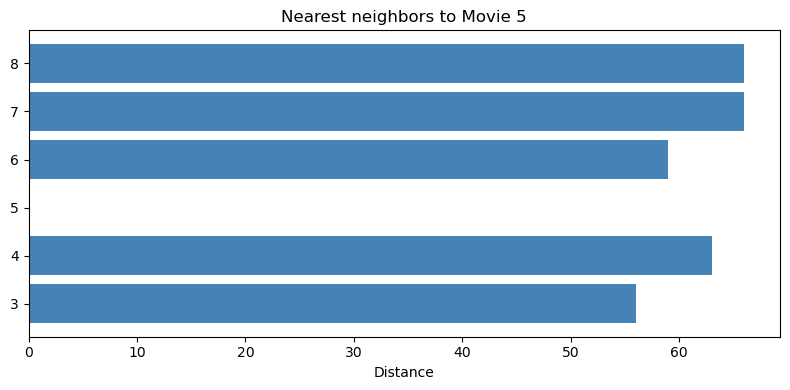

In [20]:
query_movie = matrix.index[query_man]
neighbor_movies = [matrix.index[indexes_man.flatten()[i]] for i in range(len(distances_man.flatten()))]
neighbor_distances = distances_man.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies, neighbor_distances, color="steelblue")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie}")
plt.tight_layout()
plt.show()

## Using PREPROCESSING (Changing the assumed typos into their corresponding values)

In [8]:
ratings_fixed = ratings.copy()
ratings_fixed["rating"] = ratings_fixed["rating"].replace({11: 1, 55: 5})
matrix_fixed = ratings_fixed.pivot(index="MovieID", columns="UserID", values="rating").fillna(0)
matrix_fixed

UserID,0,1,2,3,4,5,6,7,8,9
MovieID,,,,,,,,,,
0,3,5,1,2,5,1,4,1,5,1
1,0,4,1,1,5,2,3,1,5,2
2,1,3,1,0,5,3,4,1,5,3
3,5,2,5,4,1,4,1,1,4,4
4,4,1,5,4,1,5,1,0,4,5
5,2,2,4,4,1,4,1,0,4,5
6,5,3,4,4,1,3,0,0,1,5
7,0,4,2,2,1,2,0,3,2,5
8,2,5,2,2,1,1,0,3,3,4


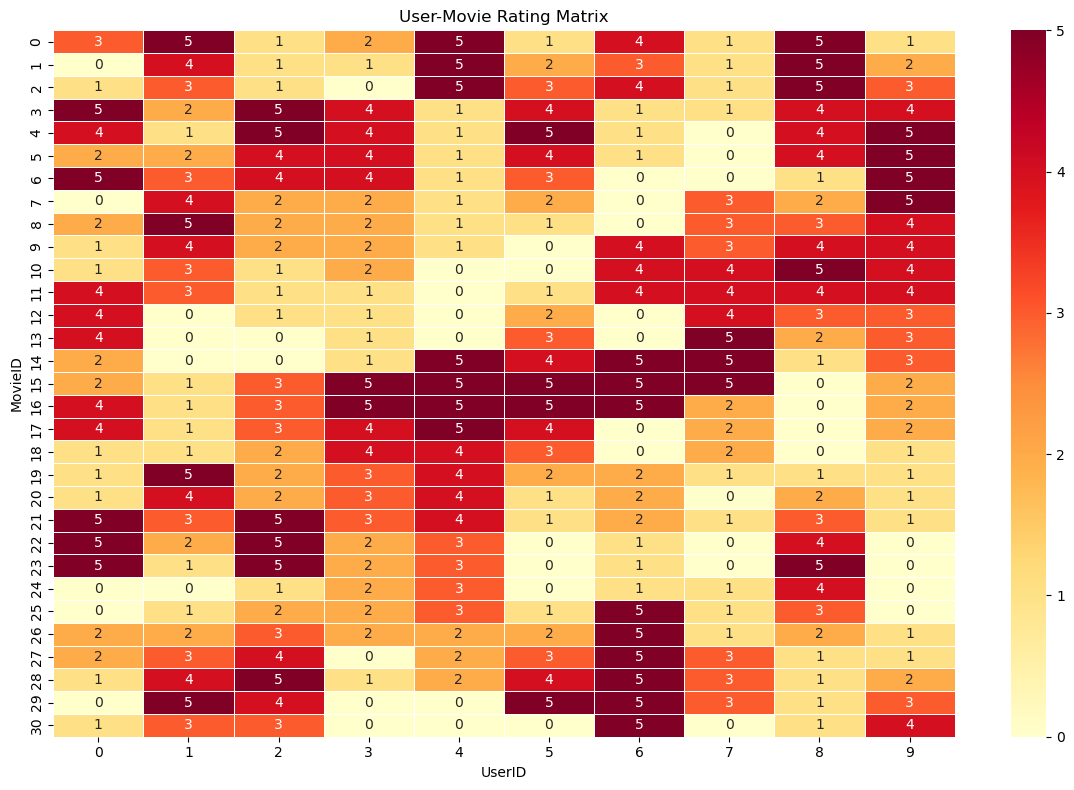

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(matrix_fixed, 
            annot=True,        # show the numbers inside cells
            fmt=".0f",         # no decimal places
            cmap="YlOrRd",     # color scale: yellow = low, red = high
            linewidths=0.5)    # grid lines between cells

plt.title("User-Movie Rating Matrix")
plt.xlabel("UserID")
plt.ylabel("MovieID")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.neighbors import NearestNeighbors

#We initialise the NearestNeighbors model to the knn_algo_eu and specify the euclidean metric 
#and brute algorithm : compare the one movie with all the others by computing the euclidean distances and comparing whihc is the highest values
knn_algo_eu_fixed = NearestNeighbors(metric="euclidean", algorithm="brute")

#fit the NearestNieghbors model to our dataset
knn_algo_eu_fixed.fit(matrix_fixed)

#query_eu=1
movie_name0_fixed = input("QUERY : Please enter your movie title : ")
query_eu_fixed = movies[movies["Title"] == movie_name0_fixed]["movieId"].values[0]

distances_eu_fixed, indexes_eu_fixed = knn_algo_eu_fixed.kneighbors(matrix_fixed.iloc[query_eu_fixed,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix_fixed.index[query_eu_fixed]}, {movie_name0_fixed}, are :")
print()
for i in range(1, len(distances_eu_fixed.flatten())):
    movie_eu_idx_fixed = matrix_fixed.index[indexes_eu_fixed.flatten()[i]]
    title_fixed = movies[movies["movieId"] == movie_eu_idx_fixed]["Title"].values[0]
    distance_eu_fixed = distances_eu_fixed.flatten()[i]
    print(f'recommended movie {movie_eu_idx_fixed}, {title_fixed}, with a Euclidean distance of {distance_eu_fixed}')

QUERY : Please enter your movie title :  The Proposal


The Recommendations for movie 5, The Proposal, are :

recommended movie 4, The Time Traveler's Wife, with a Euclidean distance of 2.6457513110645907
recommended movie 3, The Ugly Truth, with a Euclidean distance of 3.4641016151377544
recommended movie 6, The Invention of Lying, with a Euclidean distance of 4.58257569495584
recommended movie 7, The Heartbreak Kid, with a Euclidean distance of 5.830951894845301
recommended movie 8, The Duchess, with a Euclidean distance of 6.164414002968976


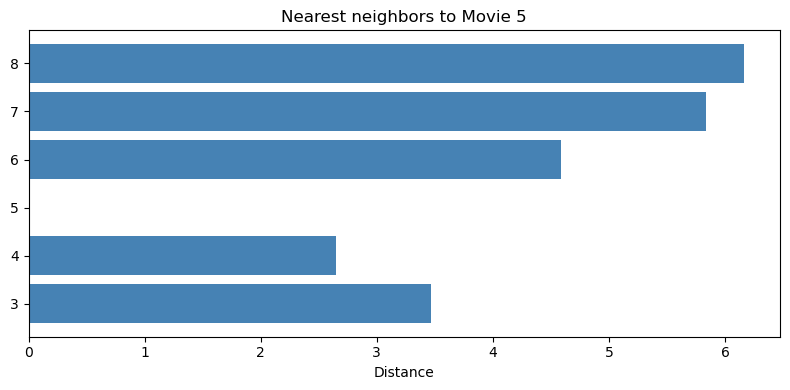

In [22]:
query_movie = matrix_fixed.index[query_eu_fixed]
neighbor_movies = [matrix_fixed.index[indexes_eu_fixed.flatten()[i]] for i in range(len(distances_eu_fixed.flatten()))]
neighbor_distances = distances_eu_fixed.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies, neighbor_distances, color="steelblue")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie}")
plt.tight_layout()
plt.show()

In [14]:
knn_algo_man_fixed = NearestNeighbors(metric="manhattan", algorithm="brute")

knn_algo_man_fixed.fit(matrix_fixed)

#query_man=1
movie_name1_fixed = input("QUERY : Please enter your movie title : ")
query_man_fixed = movies[movies["Title"] == movie_name1_fixed]["movieId"].values[0]

distances_man_fixed, indexes_man_fixed = knn_algo_man_fixed.kneighbors(matrix_fixed.iloc[query_man_fixed,:].values.reshape(1,-1), n_neighbors=6)

print(f"The Recommendations for movie {matrix_fixed.index[query_man_fixed]}, {movie_name1_fixed}, are :")
print()
for i in range(1, len(distances_man_fixed.flatten())):
    movie_man_idx_fixed = matrix_fixed.index[indexes_man_fixed.flatten()[i]]
    title_fixed = movies[movies["movieId"] == movie_man_idx_fixed]["Title"].values[0]
    distance_man_fixed = distances_man_fixed.flatten()[i]
    print(f'recommended movie {movie_man_idx_fixed}, {title_fixed}, with a Manhattan distance of {distance_man_fixed}')

QUERY : Please enter your movie title :  The Proposal


The Recommendations for movie 5, The Proposal, are :

recommended movie 4, The Time Traveler's Wife, with a Manhattan distance of 5.0
recommended movie 3, The Ugly Truth, with a Manhattan distance of 6.0
recommended movie 6, The Invention of Lying, with a Manhattan distance of 9.0
recommended movie 7, The Heartbreak Kid, with a Manhattan distance of 16.0
recommended movie 8, The Duchess, with a Manhattan distance of 16.0


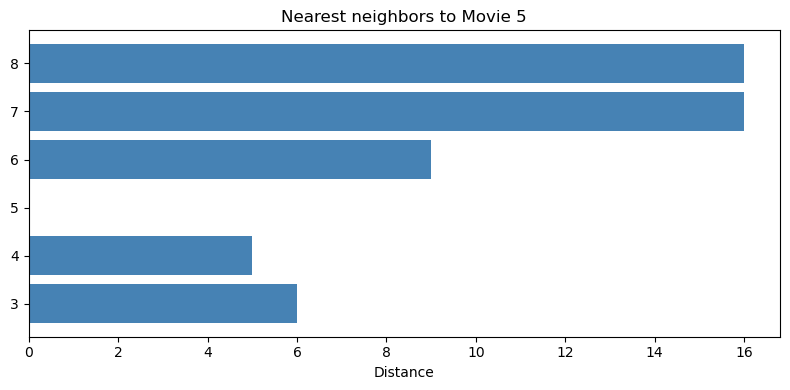

In [23]:
query_movie = matrix.index[query_man_fixed]
neighbor_movies = [matrix_fixed.index[indexes_man_fixed.flatten()[i]] for i in range(len(distances_man_fixed.flatten()))]
neighbor_distances = distances_man_fixed.flatten()

plt.figure(figsize=(8, 4))
plt.barh(neighbor_movies, neighbor_distances, color="steelblue")
plt.xlabel("Distance")
plt.title(f"Nearest neighbors to Movie {query_movie}")
plt.tight_layout()
plt.show()